In [1]:
import numpy as np
import scipy as sci
import numpy.linalg as linal
import sympy as sp
import matplotlib.pyplot as plt
import pandas as pd

In [122]:
# w = sp.symbols('w')
# t = sp.symbols('t')
a = 1.2
# xt = sp.Piecewise((sp.exp(-1/(a**2 - t**2)),(-a<t)&(t<a)),(0,(t<-a)&(t>a)))

In [123]:
def func(t) : 
    return np.exp(-2/(a**2 - t**2))

def ft(t,w) : 
    return np.exp((-1/(a**2 - t**2)) - 1j*t*w )

In [124]:
w = np.linspace(-20,20,1000)

* Energy of signal 
$$ \int_{-a}^{a}{x(t)^2 \cdot dt} $$

In [125]:
out = []
for i in w : 
    out.append(sci.integrate.quad(ft,-a,a,args=(i)) [0])

Text(0, 0.5, 'Amplitude')

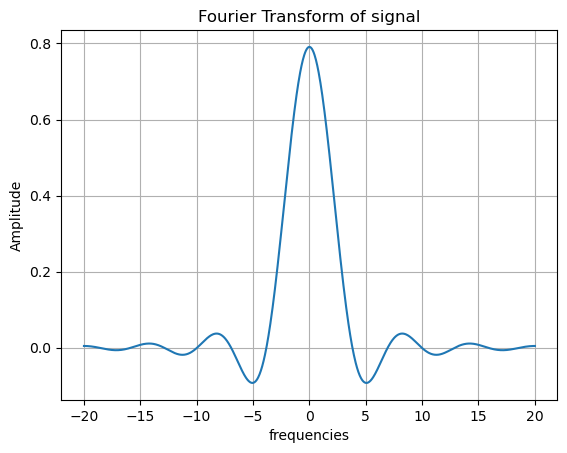

In [126]:
plt.plot(w,out)
plt.grid()
plt.title('Fourier Transform of signal')
plt.xlabel('frequencies')
plt.ylabel('Amplitude')

In [11]:
sci.integrate.quad(func, -a, a)

(0.3295705604433915, 9.634323961976561e-09)

----

In [33]:
a = 0.3446
b = 1 - a

In [34]:
(a*b + b*b + b*a + a*a)

1.0

In [35]:
b*b

0.42954916

In [36]:
from scipy.stats import norm

In [127]:
As = np.linspace(0,1,100)
p = []
q = []

for A in As :
    a = norm.cdf(A/2,A,1)
    b = 1-a
    false_detection_signal = a*b
    signal_detection = b*b
    p.append(false_detection_signal)
    q.append(signal_detection)

Text(0.5, 0, 'p')

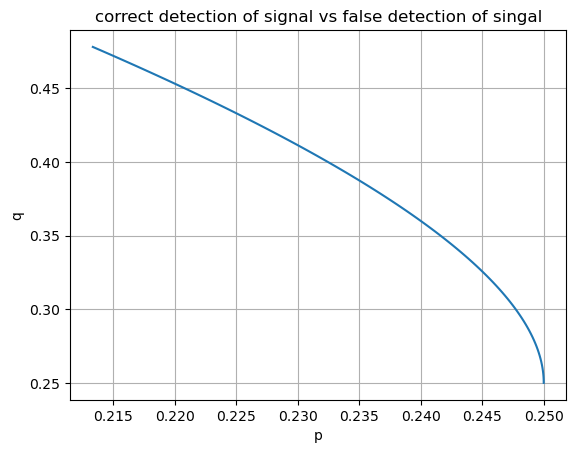

In [128]:
plt.plot(p,q)
plt.grid()
plt.title('correct detection of signal vs false detection of singal')
plt.ylabel('q')
plt.xlabel('p')

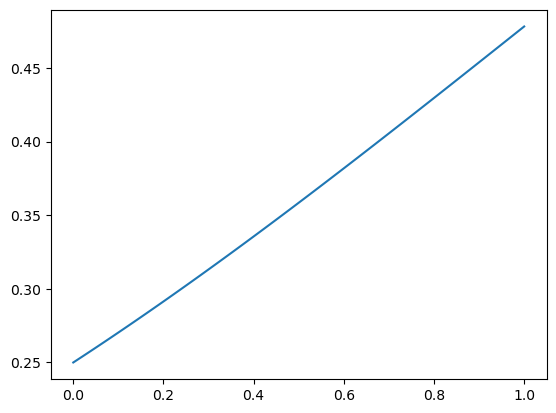

In [50]:
plt.plot(As, q)

---
3)

In [68]:
data = pd.read_csv('qset2.csv', header=None)
data.var()

0    1773.566388
1    1678.052053
2     450.764396
3     610.625863
dtype: float64

In [58]:
var = data.to_numpy()

In [70]:
vars = np.diag(var.T@var)/1000

In [76]:
(var.T@var/1000)[0,3]/np.sqrt(vars[0]*vars[3])

0.9526671936723856

In [73]:
var.T@var/1000

array([[1772.66828801, 1711.44122767,  884.61055609,  990.84363025],
       [1711.44122767, 1676.96274317,  843.69175981,  937.813489  ],
       [ 884.61055609,  843.69175981,  450.55236962,  511.85645606],
       [ 990.84363025,  937.813489  ,  511.85645606,  610.23954585]])

In [77]:
var2 = var[:,[1,2,3]]

In [81]:
C = var2.T@var2/1000

In [85]:
C_ = (var.T@var/1000)[[1,2,3],0]

In [90]:
C_ = np.column_stack(C_).T

In [91]:
linal.inv(C)@C_

array([[ 0.5446451 ],
       [ 1.05698182],
       [-0.09988677]])

---
4)

In [94]:
k1 = 1
k2 = 1
l1 = 1
l2 = 2

In [97]:
k2*l2*l2 + k1*l1*l1

5

In [135]:
w = np.linspace(0,50,1000)
def frf(w) : 
    return np.abs(9*w**2 - 9 - 2*w**4)

Text(0, 0.5, 'FRF')

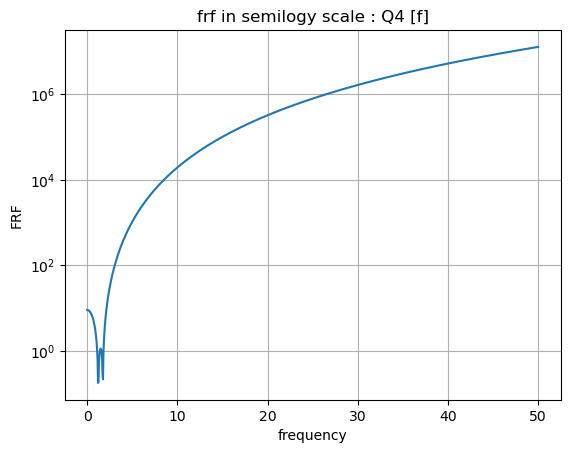

In [136]:
plt.semilogy(w,frf(w))
plt.grid()
plt.title('frf in semilogy scale : Q4 [f]')
plt.xlabel('frequency')
plt.ylabel('FRF')

In [108]:
def irf(t) :
    return ( np.sqrt(3)*np.sin(np.sqrt(3)*t) - np.sqrt(6)*np.sin(np.sqrt(1.5)*t) )/9

Text(0, 0.5, 'IRF')

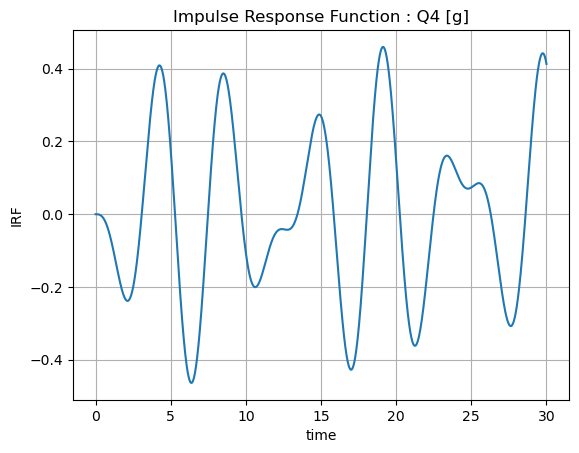

In [116]:
t = np.linspace(0,30,2000)
plt.plot(t,irf(t))
plt.grid()
plt.title('Impulse Response Function : Q4 [g]')
plt.xlabel('time')
plt.ylabel('IRF')